In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(
    str(project_root / "src")
)

In [13]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

from atlas.embeddings import (
    EmbeddingModel
)

In [3]:
g_autokaggle = nx.read_graphml(
    "../data/graphs/autokaggle.graphml"
)

g_aide = nx.read_graphml(
    "../data/graphs/aide.graphml"
)

g_data_interpreter = nx.read_graphml(
    "../data/graphs/datainterpreter.graphml"
)

g_ai_scientist = nx.read_graphml(
    "../data/graphs/ai_scientist.graphml"
)

g_swe_agent = nx.read_graphml(
    "../data/graphs/swe_agent.graphml"
)

g_openhands = nx.read_graphml(
    "../data/graphs/openhands.graphml"
)

In [4]:
paper_names = {
    "AutoKaggle",
    "AIDE",
    "Data Interpreter",
    "The AI Scientist",
    "SWE-agent",
    "OpenHands"
}

all_concepts = set()

for graph in [
    g_autokaggle,
    g_aide,
    g_data_interpreter,
    g_ai_scientist,
    g_swe_agent,
    g_openhands
]:

    for node in graph.nodes():

        if node not in paper_names:
            all_concepts.add(node)

all_concepts = sorted(
    list(all_concepts)
)

print(
    len(all_concepts)
)

44


In [5]:
model = EmbeddingModel()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [6]:
matches = []

for i, concept_a in enumerate(all_concepts):

    for concept_b in all_concepts[i+1:]:

        score = model.similarity(
            concept_a,
            concept_b
        )

        if score >= 0.60:

            matches.append(
                (
                    concept_a,
                    concept_b,
                    score
                )
            )

In [7]:
matches = sorted(
    matches,
    key=lambda x: x[2],
    reverse=True
)

len(matches)

15

In [8]:
matches[:50]

[('SWE-BENCH', 'SWE-bench', np.float32(1.0000001)),
 ('frontier large language models',
  'large language models',
  np.float32(0.84802437)),
 ('Agent-Computer Interface', 'Multi-Agent System', np.float32(0.7247398)),
 ('Language Model Agent', 'large language models', np.float32(0.6817878)),
 ('Agent-Computer Interface', 'agent workflow', np.float32(0.6738309)),
 ('AI agents', 'Agent-Computer Interface', np.float32(0.6695256)),
 ('large language models',
  'transformer-based language modeling',
  np.float32(0.66848755)),
 ('Multi-Agent System', 'agent workflow', np.float32(0.65281594)),
 ('Language Model Agent',
  'transformer-based language modeling',
  np.float32(0.65182054)),
 ('AI agents', 'Multi-Agent System', np.float32(0.6514053)),
 ('LLM-based agent', 'LLMs', np.float32(0.64526737)),
 ('AI agents', 'machine learning engineering agent', np.float32(0.6449552)),
 ('Kaggle Competitions', 'Kaggle evaluations', np.float32(0.6389116)),
 ('AI agents', 'Language Model Agent', np.float32

In [9]:
df_matches = pd.DataFrame(
    matches,
    columns=[
        "Concept A",
        "Concept B",
        "Similarity"
    ]
)

df_matches.head(50)

,Concept A,Concept B,Similarity
0,SWE-BENCH,SWE-bench,1.000000
1,frontier large language models,large language models,0.848024
2,Agent-Computer Interface,Multi-Agent System,0.724740
3,Language Model Agent,large language models,0.681788
4,Agent-Computer Interface,agent workflow,0.673831
5,AI agents,Agent-Computer Interface,0.669526
6,large language models,transformer-based language modeling,0.668488
7,Multi-Agent System,agent workflow,0.652816
8,Language Model Agent,transformer-based language modeling,0.651821
9,AI agents,Multi-Agent System,0.651405


### Concept Graph

In [11]:
import networkx as nx

concept_graph = nx.Graph()

for concept_a, concept_b, score in matches:

    concept_graph.add_edge(
        concept_a,
        concept_b,
        weight=float(score)
    )

print(
    concept_graph.number_of_nodes(),
    concept_graph.number_of_edges()
)

15 15


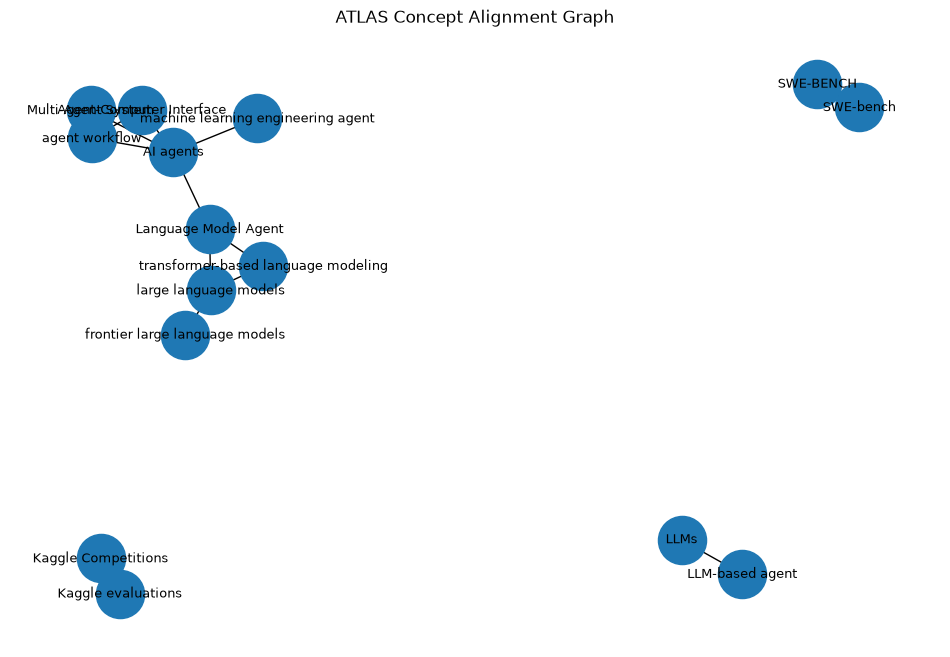

In [14]:
plt.figure(
    figsize=(12, 8)
)

pos = nx.spring_layout(
    concept_graph,
    seed=42
)

nx.draw_networkx_nodes(
    concept_graph,
    pos,
    node_size=1200
)

nx.draw_networkx_edges(
    concept_graph,
    pos
)

nx.draw_networkx_labels(
    concept_graph,
    pos,
    font_size=9
)

plt.title(
    "ATLAS Concept Alignment Graph"
)

plt.axis("off")

plt.show()

In [16]:
components = list(
    nx.connected_components(
        concept_graph
    )
)

len(components)

4

In [17]:
for i, component in enumerate(components):

    print(
        f"\nCluster {i+1}"
    )

    print(
        sorted(component)
    )


Cluster 1
['SWE-BENCH', 'SWE-bench']

Cluster 2
['AI agents', 'Agent-Computer Interface', 'Language Model Agent', 'Multi-Agent System', 'agent workflow', 'frontier large language models', 'large language models', 'machine learning engineering agent', 'transformer-based language modeling']

Cluster 3
['LLM-based agent', 'LLMs']

Cluster 4
['Kaggle Competitions', 'Kaggle evaluations']


In [18]:
model.similarity(
    "LLM-based agent",
    "Language Model Agent"
)

np.float32(0.51697433)

In [19]:
model.similarity(
    "LLM-based agent",
    "AI agents"
)

np.float32(0.56452787)

Semantic alignment successfully recovers agent- and benchmark-related concept clusters. However, abbreviation expansion remains a significant challenge, causing semantically equivalent concepts such as "LLM-based agent" and "Language Model Agent" to remain disconnected.